In [8]:
import os
# use cpu
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [9]:
! uv pip install ../.[training] --no-deps

Using Python 3.11.14 environment at: /home/dmp131/anaconda3/envs/basenji
Resolved 1 package in 3ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshar

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image

def display_images(image_path1, image_path2):
        # read images
        img_A = mpimg.imread(image_path1)
        img_B = mpimg.imread(image_path2)

        # pad top with white space
        larger = max(img_A.shape[0], img_B.shape[0])
        img_A = np.pad(img_A, ((larger - img_A.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)
        img_B = np.pad(img_B, ((larger - img_B.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)

        # stack
        img = np.concatenate((img_A, img_B), axis=1)
        # save tmp image
        tmp_path = 'tmp.png'
        plt.imsave(tmp_path, img)
        return Image(tmp_path, width=600)

In [ ]:
model = '/mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/hESC_DNA_only.ckpt'

chrom = 'chr15'
start = 60000000
region = 'chr15:60400949-61300000'
ko_start = 60500000
ko_width = 20000

In [12]:
! python ../src/cshark/inference/akita_predict.py \
    --celltype IMR90_65pct_10kb_deeploop \
    --outname akita \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/corigami_base.ckpt \
    --seq /home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --region $region \
    --min-val-pred 0.0 \
    --bigwigs ctcf=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/ctcf.bw \
              atac=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/atac.bw \
    --silent

2026-01-22 16:04:02.449042: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-22 16:04:02.520063: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 16:04:04.323852: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769115845.004818 2593411 gpu_device.cc:2020] Created device /job:lo

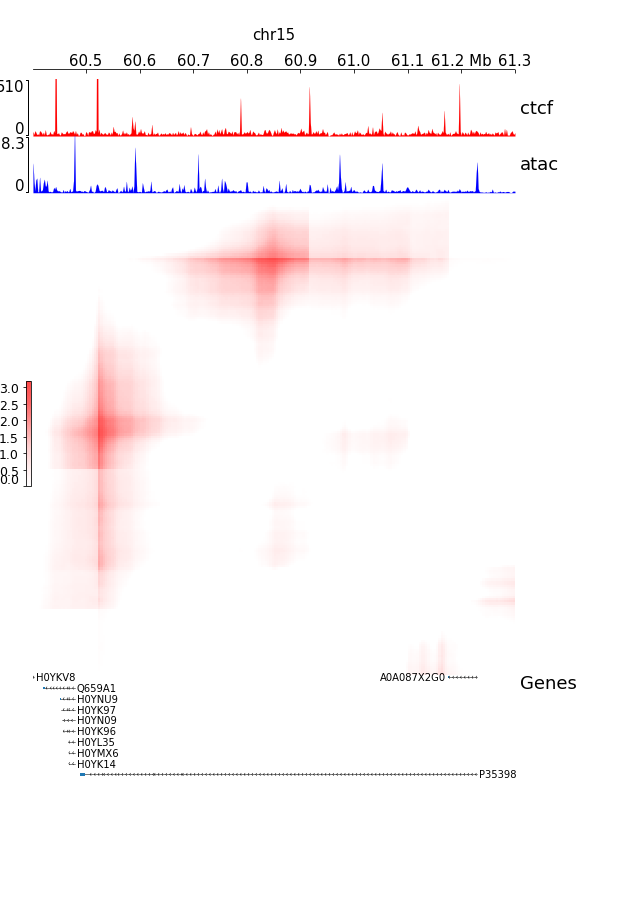

In [13]:
Image('outputs/akita_IMR90_65pct_10kb_deeploop_chr15_60000000_ctcf_pred_tracks.png', width=300)

In [18]:
! python ../src/cshark/inference/akita_predict.py \
    --celltype IMR90_65pct_10kb_deeploop \
    --outname akita \
    --chr $chrom \
    --out-file outputs/akita_chr15.tsv \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/corigami_base.ckpt \
    --seq /home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --min-val-pred 0.0 \
    --bigwigs ctcf=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/ctcf.bw \
              atac=/home/xxl1432/HiCorr_Deeploop/11.C.shark/cshark_data/data/hg38/IMR90_65pct_10kb_deeploop/genomic_features/atac.bw \
    --silent

2026-01-22 16:31:56.110638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-22 16:31:56.192515: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 16:31:58.135600: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769117518.748868 2951304 gpu_device.cc:2020] Created device /job:lo